In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d
from scipy.optimize import root
import importlib
import classy
from scipy.special import sici
from classy import Class


In [2]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'omega_b':0.0223828,
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':1,
'background_verbose':3,
'output':'mTk, vTk, mPk',
'P_k_max_1/Mpc':10,
'z_max_pk':1000,
'format':'class',
}
print(1.e-26* _ev_to_HO_)

6896120.03068243


In [3]:
# ChatGPT says that 1 eV = 4.827e19 invMpc
chiCDM = Class()
chiCDM.set(common_settings)

m_ev = 1.e-27
chiCDM.set({
    'omega_cdm': 0.12,
    'scf_potential': 'axion',
    'n_axion': 1,
    'f_axion': 0.4,  # in units of mpl
    'Omega_scf' : 0.02,
    'm_axion': m_ev * _ev_to_HO_,  # in units of H0
    'tol_shooting_deltax': 1e-4,
    'tol_shooting_deltaF': 1e-4,
    'scf_parameters': '0.05,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
    'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
    'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
    'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
    'threshold_scf_fluid_m_over_H': 3,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
    'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
    'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
    'scf_has_perturbations': 'yes',  # for pedagogical purposes only
    'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
    'use_delta_scf_over_1plusw': 'no',
    'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
    'evolver': 0
})

chiCDM.compute()
#get the growth factor of a LCDM equivalent
pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({
    'N_ur': 3.046,
    'omega_cdm':0.12,

})
pureCDM.compute()


Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.532559 Gyr
 -> conformal age = 13809.792154 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.02, wished 0.02
Additional scf parameters used: 
n = 1.000000e+00 m_a = 9.974627e-28 eV, f_a/mpl = 4.000000e-01
     -> theta_ini = 4.750114e-01 	 phi_ini = 1.900045e-01 
     -> Exact log10(z_c) = 1.048969e+00 	 f_ede = 6.039952e-02 log10 f_ede = -1.218966e+00
     -> phi(z_c) = 1.065827e-01 
     -> Omega_Lambda = 0.67026, wished 0.67026
 -> radiation/matter equality at z = 3623.054055
    corresponding to conformal time = 106.371339 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972        , omega 

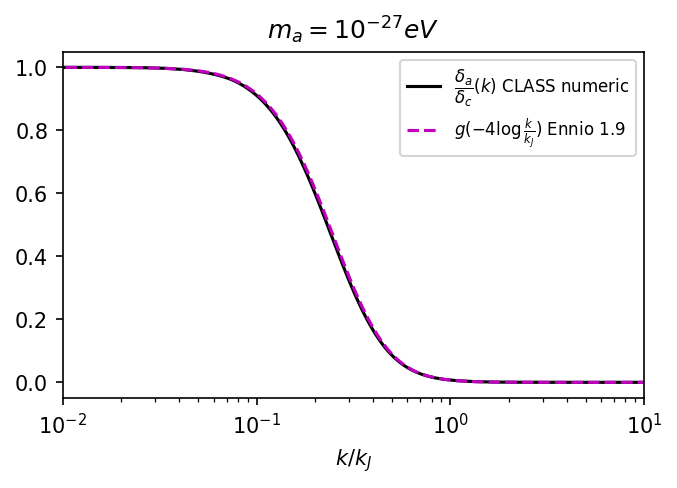

In [4]:
zeval = 0.5
chi_tk_k = chiCDM.get_transfer(z=zeval)

kEval=chi_tk_k['k (h/Mpc)']
d_ax_k=-chi_tk_k['d_scf']
d_cdm_k=-chi_tk_k['d_cdm']

T_ratio_k =d_ax_k/ d_cdm_k

def g_an(t):
    return  1 + 6 * np.exp(-t) * np.cos(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[1] - 3 * np.exp(-t) * np.pi * np.sin(np.sqrt(6) * np.exp(-t / 2)) + 6 * np.exp(-t) * np.sin(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[0]

# H0p5 = Ha_chi_int(0.666)/0.666
# kJ0p5 = np.sqrt(H0p5 * m_ax)/0.67810
# kJest = np.sqrt(3.336e-04 * h * m_ev * 1.56e29)/h * (0.6666)**0.25

kJest =3.9e-4 * pow(m_ev*_ev_to_HO_,1/2) * pow(1/(1+0.5),1/4)
# kJest =8.4e12 * pow(m_ev/h,1/2) * 0.666**0.25

plt.figure(figsize=(5,3), dpi=150)
plt.plot(kEval, T_ratio_k,'k',label=r'$\dfrac{\delta_a}{\delta_c}(k)$ CLASS numeric')
plt.plot(kEval, g_an(-4*np.log(kEval/(kJest))),'m--',label=r'$g(-4\log \frac{k}{k_J})$ Ennio 1.9')

plt.xscale('log')
plt.xlabel(r'$k/k_J$')
plt.legend(loc='upper right', fontsize=8)
plt.xlim([1.e-2,1.e1])
plt.title(r'$m_a = 10^{-27}eV$')
plt.show()

-----
Now neutrini

In [9]:
nuCDM = Class()
nuCDM.set(common_settings)
# pass input parameters
Mnu=0.06

nuCDM = Class()
nuCDM.set(common_settings)
nuCDM.set({
    'N_ur': 2.0328,
    # 'N_ncdm':1,
    # 'm_ncdm':Mnu,
    'N_ncdm':3,
    'm_ncdm':'0.02,0.02,0.02',
    # 'ncdm_fluid_approximation':0,
})


nuCDM.compute()

Running CLASS version v3.2.0
Computing background
 fraction of ncdm is 5.365720e-03 
 -> non-cold dark matter species with i=1 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> non-cold dark matter species with i=2 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> non-cold dark matter species with i=3 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=2 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> ncdm species i=2 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=3 has m_i = 2.0

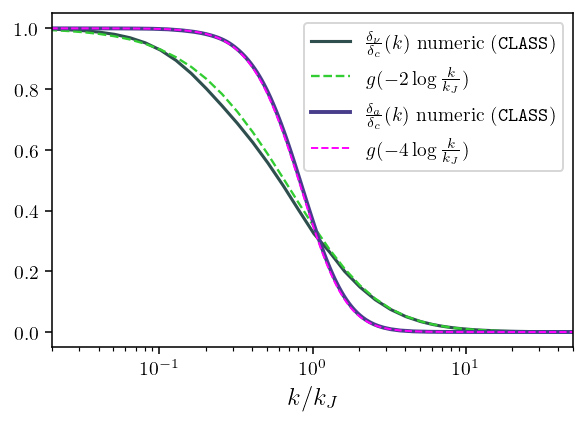

In [42]:
zeval = 0.5
chi_tk_k = nuCDM.get_transfer(z=zeval)

kEval=chi_tk_k['k (h/Mpc)']
d_nu_k=-chi_tk_k['d_ncdm[0]']
d_cdm_k=-chi_tk_k['d_cdm']


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})
plt.figure(figsize=(4.8,3.1), dpi=140)

# kJestnu =0.155 * (Mnu/0.3) * pow(0.666,1/2)
kJestnu =5.e-2 * (Mnu/0.3) * pow(0.666,1/2)

plt.plot(kEval/kJestnu, d_nu_k/d_cdm_k,'darkslategray', linewidth=1.6,label=r'$\frac{\delta_\nu}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
plt.plot(kEval/kJestnu, g_an(-2*np.log(kEval/(kJestnu))),'limegreen', linestyle='--', linewidth=1.2,label=r'$g(-2\log \frac{k}{k_J})$ ')

plt.plot(kEval/kJest, T_ratio_k,'darkslateblue', linewidth=2.,label=r'$\frac{\delta_a}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
plt.plot(kEval/kJest, g_an(-4*np.log(kEval/(kJest))),'fuchsia', linestyle='--', linewidth=1.,label=r'$g(-4\log \frac{k}{k_J})$')

plt.xscale('log')
plt.xlabel(r'$k/k_J$', fontsize=13)
plt.legend(loc='upper right', fontsize=10)
plt.xlim([2.e-2,5.e1])
# plt.savefig('/home/fverdian/class/soundspeed-scripts/lincompare.pdf', bbox_inches='tight')
plt.show()

Running CLASS version v3.2.0
Computing background
 fraction of ncdm is 5.365720e-03 
 -> non-cold dark matter species with i=1 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> non-cold dark matter species with i=2 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> non-cold dark matter species with i=3 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=2 has m_i = 2.000000e-02 eV (so m_i / omega_i =9.310074e+01 eV)
 -> ncdm species i=2 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=3 has m_i = 2.0

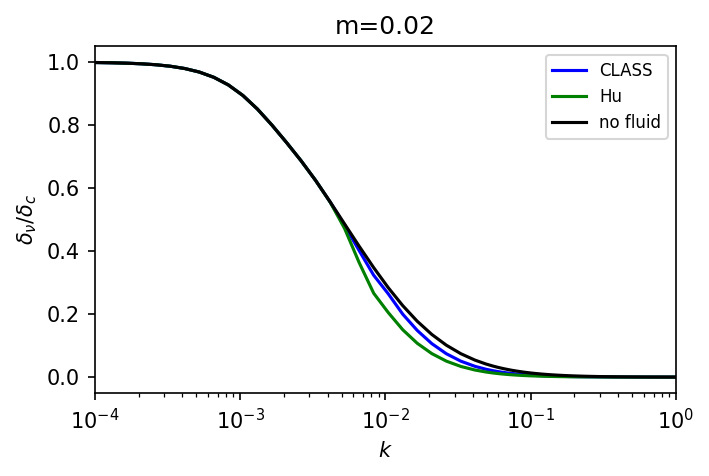

In [16]:
nuCDM = Class()

nuCDM.set(common_settings)
nuCDM.set({
    'N_ur': 2.0328,
    'N_ncdm':3,
    'm_ncdm':'0.02,0.02,0.02',
    'ncdm_fluid_approximation':2.,
})

nuCDM.compute()

plt.figure(figsize=(5,3), dpi=150)

chi_tk_k = nuCDM.get_transfer(z=0.5)
kEval=chi_tk_k['k (h/Mpc)']
plt.plot(kEval, chi_tk_k['d_ncdm[0]']/chi_tk_k['d_cdm'],'b',label=r'CLASS')

nuCDM.set({'ncdm_fluid_approximation':1.,})
nuCDM.compute()

chi_tk_k = nuCDM.get_transfer(z=0.5)
kEval=chi_tk_k['k (h/Mpc)']
plt.plot(kEval, chi_tk_k['d_ncdm[0]']/chi_tk_k['d_cdm'],'g',label=r'Hu')

nuCDM.set({'ncdm_fluid_approximation':3.,})
nuCDM.compute()

chi_tk_k = nuCDM.get_transfer(z=0.5)
kEval=chi_tk_k['k (h/Mpc)']
plt.plot(kEval, chi_tk_k['d_ncdm[0]']/chi_tk_k['d_cdm'],'k',label=r'no fluid')

plt.xscale('log')
plt.xlabel(r'$k$')
plt.ylabel(r'$\delta_\nu/\delta_c$')

plt.legend(loc='upper right', fontsize=8)
plt.xlim([1.e-4,1.e0])
plt.title('m=0.02')
plt.show()